# 1. Define the problem

- Target variable -> sales
- That's a regression problem, we need a number as output
- R2 -> success metric

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [13]:
sales = pd.read_csv('./sales.csv')

display(sales.head(10))
display(sales.sample(10))
display(sales.tail(10))

display(sales.shape)
display(sales.columns)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
5,687329,674,2,2013-03-19,1016,1,1,0,0,8406
6,600327,659,7,2014-06-08,0,0,0,0,0,0
7,96265,27,3,2014-07-16,1106,1,1,0,1,11162
8,364435,347,6,2013-05-11,448,1,0,0,0,5559
9,163146,288,2,2013-06-25,291,1,0,0,0,3997


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
370100,483511,132,4,2014-01-30,491,1,0,0,0,5207
414828,532126,100,1,2014-04-14,823,1,1,0,1,10556
601138,325895,784,1,2015-04-06,0,0,0,b,1,0
12424,471055,709,3,2015-04-15,1440,1,1,0,0,10698
473590,426342,525,7,2014-12-14,0,0,0,0,0,0
544810,649795,345,3,2014-03-05,555,1,1,0,1,5525
497082,238833,1055,4,2013-01-17,856,1,0,0,0,6233
479004,263299,204,5,2013-11-29,582,1,0,0,0,6392
61667,321762,131,1,2015-03-30,677,1,1,0,1,7287
154743,577851,433,5,2014-01-24,625,1,1,0,0,5682


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
640830,374564,955,4,2013-04-11,386,1,1,0,0,3745
640831,448242,341,3,2014-06-11,744,1,0,0,0,5451
640832,610581,359,4,2015-05-07,615,1,1,0,0,6881
640833,122579,77,6,2015-01-17,701,1,0,0,0,8219
640834,304137,329,7,2013-09-15,0,0,0,0,0,0
640835,359783,409,6,2013-10-26,483,1,0,0,0,4553
640836,152315,97,1,2014-04-14,987,1,1,0,0,12307
640837,117952,987,1,2014-07-07,925,1,0,0,0,6800
640838,435829,1084,4,2014-06-12,725,1,0,0,0,5344
640839,305711,695,7,2015-05-03,0,0,0,0,0,0


(640840, 10)

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='object')

In [14]:
display(sales.dtypes)
display(sales['state_holiday'].unique())

Unnamed: 0              int64
store_ID                int64
day_of_week             int64
date                   object
nb_customers_on_day     int64
open                    int64
promotion               int64
state_holiday          object
school_holiday          int64
sales                   int64
dtype: object

array(['0', 'a', 'c', 'b'], dtype=object)

In [15]:
display(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


None

In [16]:
display(sales.describe())

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [17]:
print(sales.isna().sum())

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


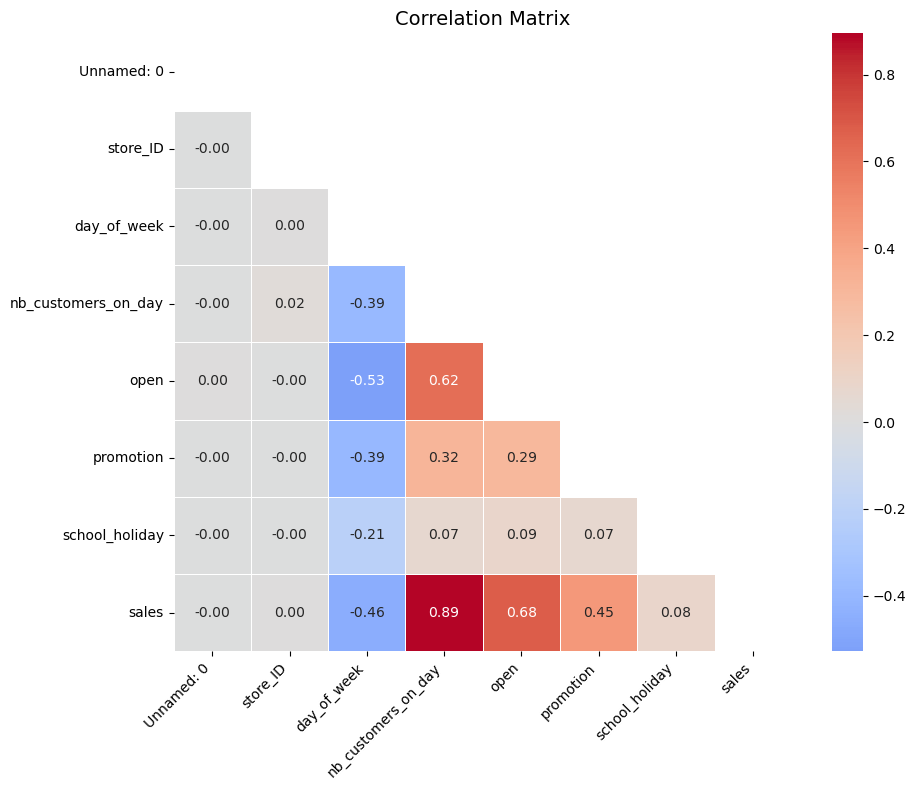


Top 3 Positive Correlations:
nb_customers_on_day  sales    0.894872
open                 sales    0.678463
nb_customers_on_day  open     0.617264
dtype: float64

Top 3 Negative Correlations:
day_of_week  promotion   -0.392736
             sales       -0.461107
             open        -0.527947
dtype: float64


In [18]:
def show_corr(df):
    """Display triangular correlation matrix"""
    # Create correlation matrix
    corr = df.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, 
                mask=mask, 
                annot=True, 
                cmap='coolwarm', 
                center=0, 
                fmt='.2f',
                square=True,
                linewidths=0.5)
    plt.title('Correlation Matrix', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print top correlations
    corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    corr_pairs = corr_pairs.stack().sort_values(ascending=False)
    
    print("\nTop 3 Positive Correlations:")
    print(corr_pairs.head(3))
    
    print("\nTop 3 Negative Correlations:")
    print(corr_pairs.tail(3))


show_corr(sales.drop(['date', 'state_holiday'], axis=1))

In [28]:
store_closed_records = sales[sales['open'] == 0]['sales']
display(store_closed_records.value_counts())

nb_customers_on_day_closed_records = sales[sales['open'] == 0]['nb_customers_on_day']
display(nb_customers_on_day_closed_records.value_counts())

sales
0    108824
Name: count, dtype: int64

nb_customers_on_day
0    108824
Name: count, dtype: int64

<Figure size 5500x2500 with 0 Axes>

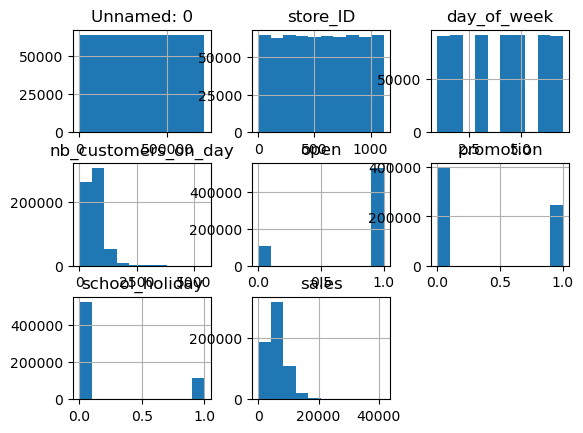

In [33]:
fig = plt.figure(figsize=(55, 25))
sales.hist()
plt.show()

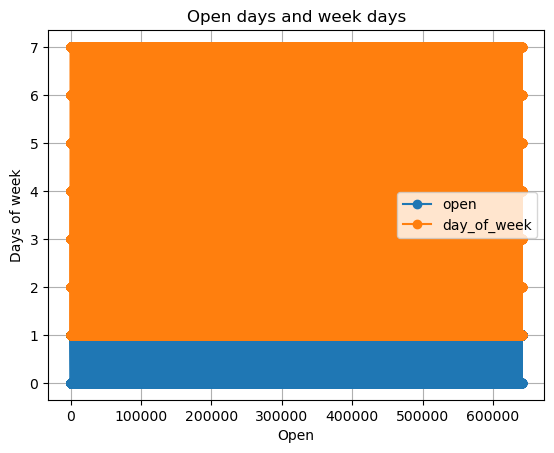

In [ ]:
# Unnamed, store_ID, date
sales[['day_of_week', 'open']].plot(kind='line', marker='o')

plt.title('Open days and week days')
plt.xlabel('Open')
plt.ylabel('Days of week')
plt.grid(True)
plt.show()